In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
df = pd.read_csv('Algerian_forest_fires_dataset.csv', header = 2)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [3]:
df.shape

(247, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 38.0 KB


In [8]:
## Data Cleaning

df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [9]:
df.isnull().any(axis = 1)

0      False
1      False
2      False
3      False
4      False
       ...  
242    False
243    False
244    False
245    False
246    False
Length: 247, dtype: bool

In [10]:
df[df.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [13]:
df.drop(122).reset_index(drop = True)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
242,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
243,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
244,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [14]:
df[df.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [15]:
df.loc[:123, "Region"] = 0
df.loc[124:, "Region"] = 1

In [16]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [17]:
df[df.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1.0


In [18]:
df[['Region']] = df[['Region']].astype('int')

In [24]:
### Handling Null Values

df.dropna().reset_index(drop = True)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1
240,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1
241,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
242,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [25]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
Region         0
dtype: int64

In [29]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [30]:
df.iloc[[123]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [31]:
df.iloc[[168]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1


In [32]:
df = df.drop(122).reset_index(drop=True)

In [33]:
df = df.drop(123).reset_index(drop=True)

In [34]:
df = df.drop(168).reset_index(drop=True)

In [35]:
df.shape

(244, 15)

In [36]:
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

In [37]:
df[df.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
166,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1


In [38]:
df = df.drop(122).reset_index(drop=True)

In [39]:
df[df.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
165,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1


In [41]:
df = df.drop(165).reset_index(drop=True)

In [42]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [43]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [44]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

In [ ]:
### Removing spaces from column names
df.columns = df.columns.str.strip()

In [46]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [47]:
df.head(2)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0


In [48]:
#### Change the required columns to integer dtype

df[['month', 'day', 'year', 'Temperature', 'RH', 'Ws']] = df[['month', 'day', 'year', 'Temperature', 'RH', 'Ws']].astype(int)

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          241 non-null    int64
 1   month        241 non-null    int64
 2   year         241 non-null    int64
 3   Temperature  241 non-null    int64
 4   RH           241 non-null    int64
 5   Ws           241 non-null    int64
 6   Rain         241 non-null    str  
 7   FFMC         241 non-null    str  
 8   DMC          241 non-null    str  
 9   DC           241 non-null    str  
 10  ISI          241 non-null    str  
 11  BUI          241 non-null    str  
 12  FWI          241 non-null    str  
 13  Classes      241 non-null    str  
 14  Region       241 non-null    int64
dtypes: int64(7), str(8)
memory usage: 35.8 KB


In [52]:
### changing the other columns to float dtype

objects = [features for features in df.columns if df[features].dtype == 'string']

In [53]:
objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [55]:
for i in objects:
    if i != 'Classes':
        df[i] = df[i].astype(float)

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          241 non-null    int64  
 1   month        241 non-null    int64  
 2   year         241 non-null    int64  
 3   Temperature  241 non-null    int64  
 4   RH           241 non-null    int64  
 5   Ws           241 non-null    int64  
 6   Rain         241 non-null    float64
 7   FFMC         241 non-null    float64
 8   DMC          241 non-null    float64
 9   DC           241 non-null    float64
 10  ISI          241 non-null    float64
 11  BUI          241 non-null    float64
 12  FWI          241 non-null    float64
 13  Classes      241 non-null    str    
 14  Region       241 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 30.4 KB


In [57]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,241.000000,241.000000,241.0,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000
mean,15.763485,7.506224,2012.0,32.149378,62.024896,15.481328,0.769295,77.762241,14.647303,49.603734,4.717012,16.675934,7.004979,0.493776
std,8.879170,1.118482,0.0,3.640411,14.787361,2.819697,2.010320,14.379480,12.438951,47.823933,4.152449,14.286509,7.457495,0.501002
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,53.000000,14.000000,0.000000,71.400000,5.800000,10.500000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.100000,11.200000,33.400000,3.300000,12.100000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.000000,17.000000,0.500000,88.300000,20.900000,71.000000,7.200000,22.900000,11.300000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [58]:
### Lets save the cleaned dataset

df.to_csv('Algerian_forest_fires_dataset_cleaned.csv', index = False)

In [59]:
####EDA

df1 = df.drop(['month', 'day', 'year'], axis = 1)

In [60]:
#### Encoding of categories in classes

df1['Classes'].value_counts()

Classes
fire             129
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [61]:
df1['Classes'] = np.where(df1['Classes'].str.contains('not fire'), 0, 1)

In [62]:
df1['Classes'].value_counts()

Classes
1    135
0    106
Name: count, dtype: int64

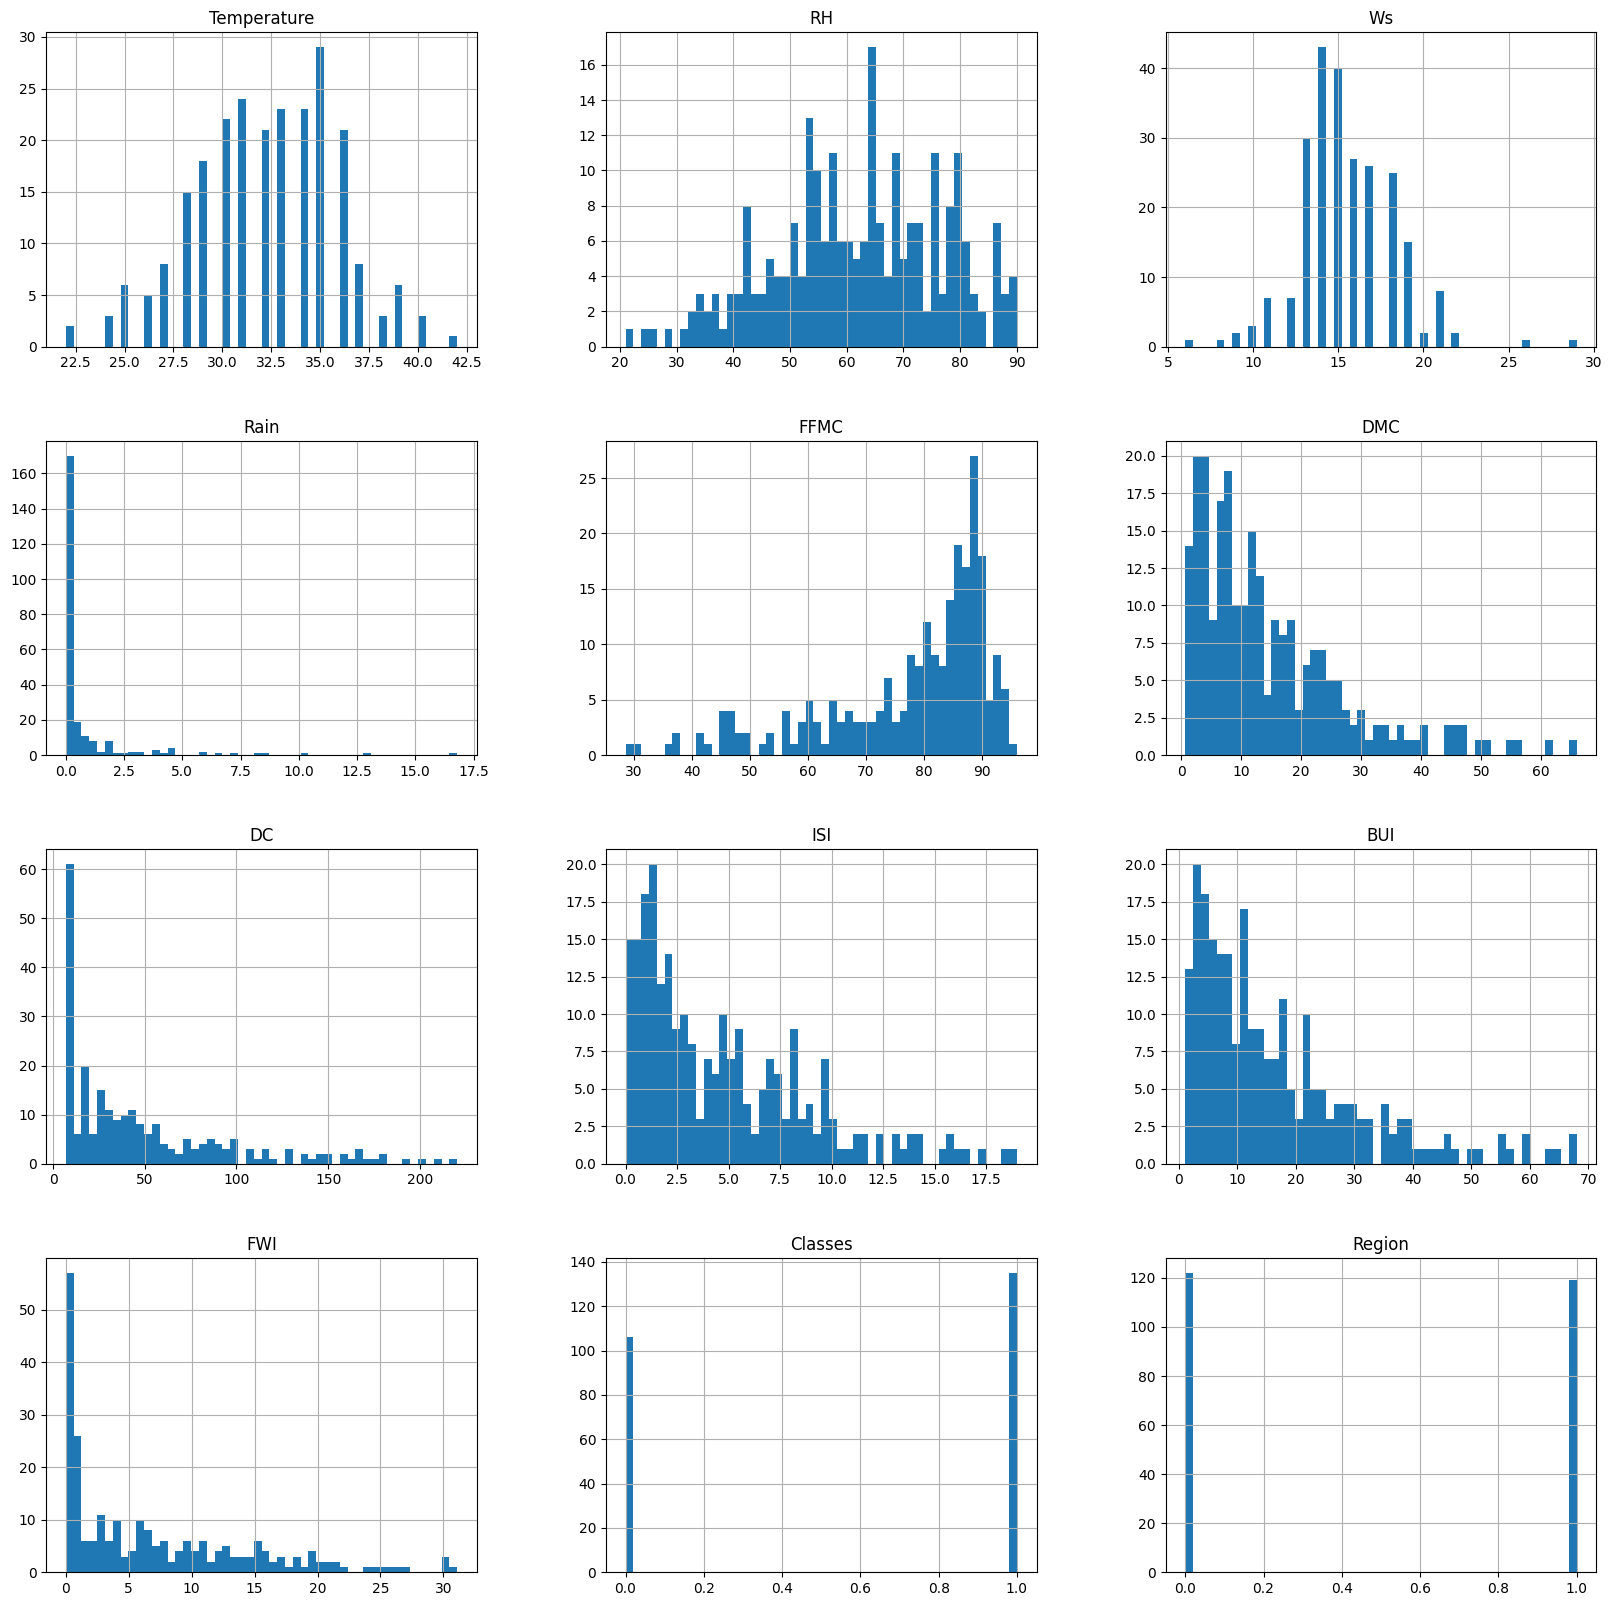

In [66]:
### Plotting density plots for all the features
# plt.style.use('seaborn-darkgrid')
df1.hist(figsize = (20, 20), bins = 50)
plt.show()

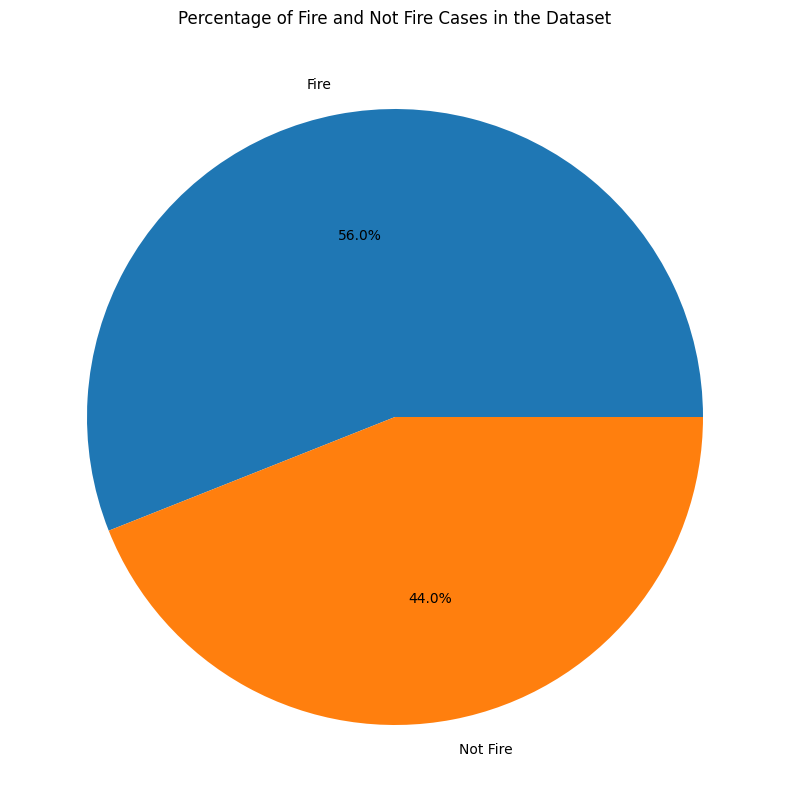

In [67]:
### Percentage of fire and not fire cases in the dataset pie chart

percentage = df1['Classes'].value_counts(normalize=True) * 100
classLabels = ['Fire', 'Not Fire']
plt.figure(figsize=(10, 10))
plt.pie(percentage, labels = classLabels, autopct = '%1.1f%%')
plt.title('Percentage of Fire and Not Fire Cases in the Dataset')
plt.show()


In [68]:
### Correlation heatmap

df1.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.652097,-0.285492,-0.326628,0.677222,0.486202,0.377551,0.603940,0.460248,0.566198,0.517362,0.270088
RH,-0.652097,1.000000,0.245439,0.224455,-0.649202,-0.412498,-0.229227,-0.687424,-0.357018,-0.581746,-0.437535,-0.408294
Ws,-0.285492,0.245439,1.000000,0.173519,-0.170108,-0.002172,0.081250,0.005276,0.030926,0.030262,-0.074210,-0.186638
Rain,-0.326628,0.224455,0.173519,1.000000,-0.543222,-0.288048,-0.299841,-0.346942,-0.299663,-0.323661,-0.377754,-0.037010
FFMC,0.677222,-0.649202,-0.170108,-0.543222,1.000000,0.603407,0.511495,0.739492,0.592680,0.690301,0.768627,0.217984
DMC,0.486202,-0.412498,-0.002172,-0.288048,0.603407,1.000000,0.878189,0.682237,0.982407,0.876786,0.585431,0.190264
DC,0.377551,-0.229227,0.081250,-0.299841,0.511495,0.878189,1.000000,0.514684,0.943254,0.743684,0.516409,-0.075464
ISI,0.603940,-0.687424,0.005276,-0.346942,0.739492,0.682237,0.514684,1.000000,0.646662,0.922996,0.735528,0.259318
BUI,0.460248,-0.357018,0.030926,-0.299663,0.592680,0.982407,0.943254,0.646662,1.000000,0.859341,0.587669,0.088755
FWI,0.566198,-0.581746,0.030262,-0.323661,0.690301,0.876786,0.743684,0.922996,0.859341,1.000000,0.719271,0.194166


<Axes: >

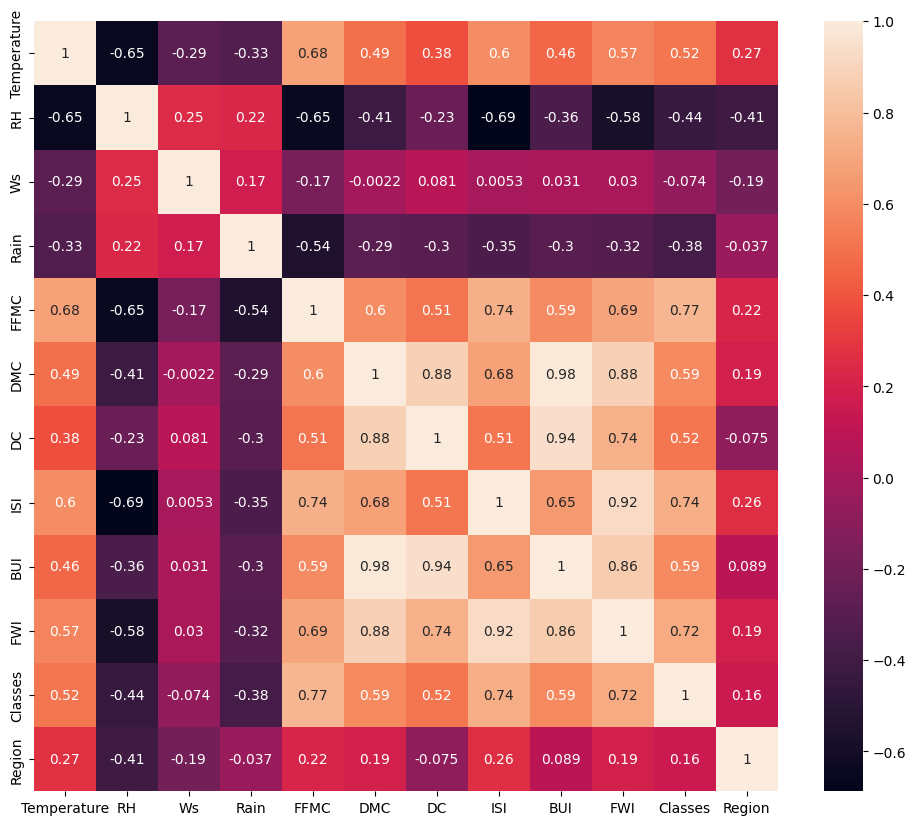

In [69]:
plt.figure(figsize=(12, 10))
sns.heatmap(df1.corr(), annot = True)

In [70]:
### Monthly Fire Analysis

df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 'Not Fire', 'Fire')

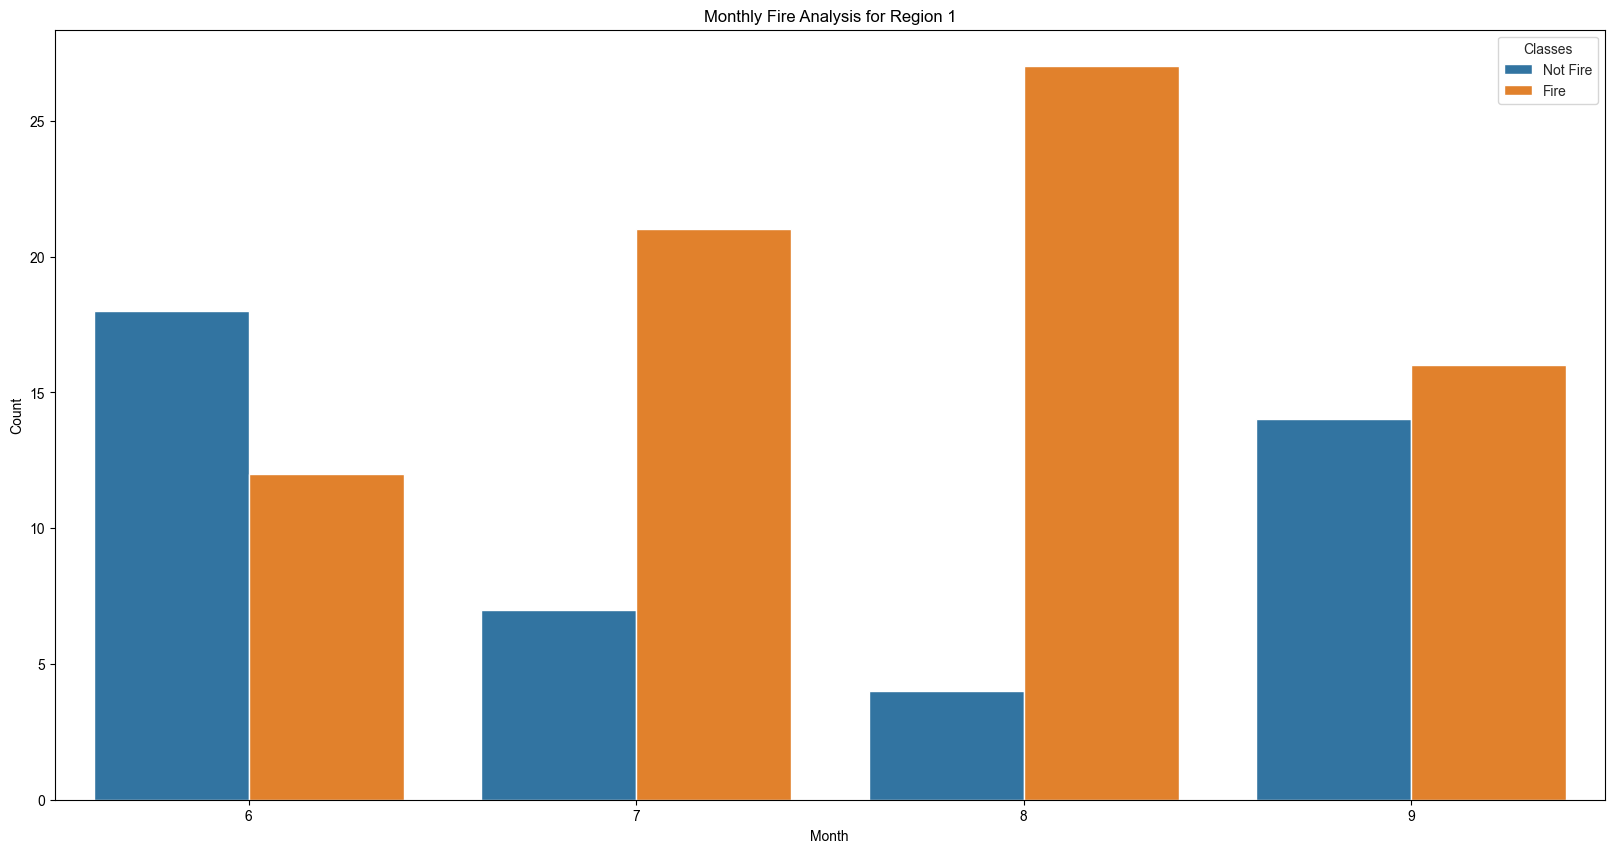

In [71]:
dftemp = df.loc[df['Region'] == 1]
plt.subplots(figsize=(20, 10))
sns.set_style('whitegrid')
sns.countplot(x = 'month', hue = 'Classes', data = dftemp)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Monthly Fire Analysis for Region 1')

plt.show()


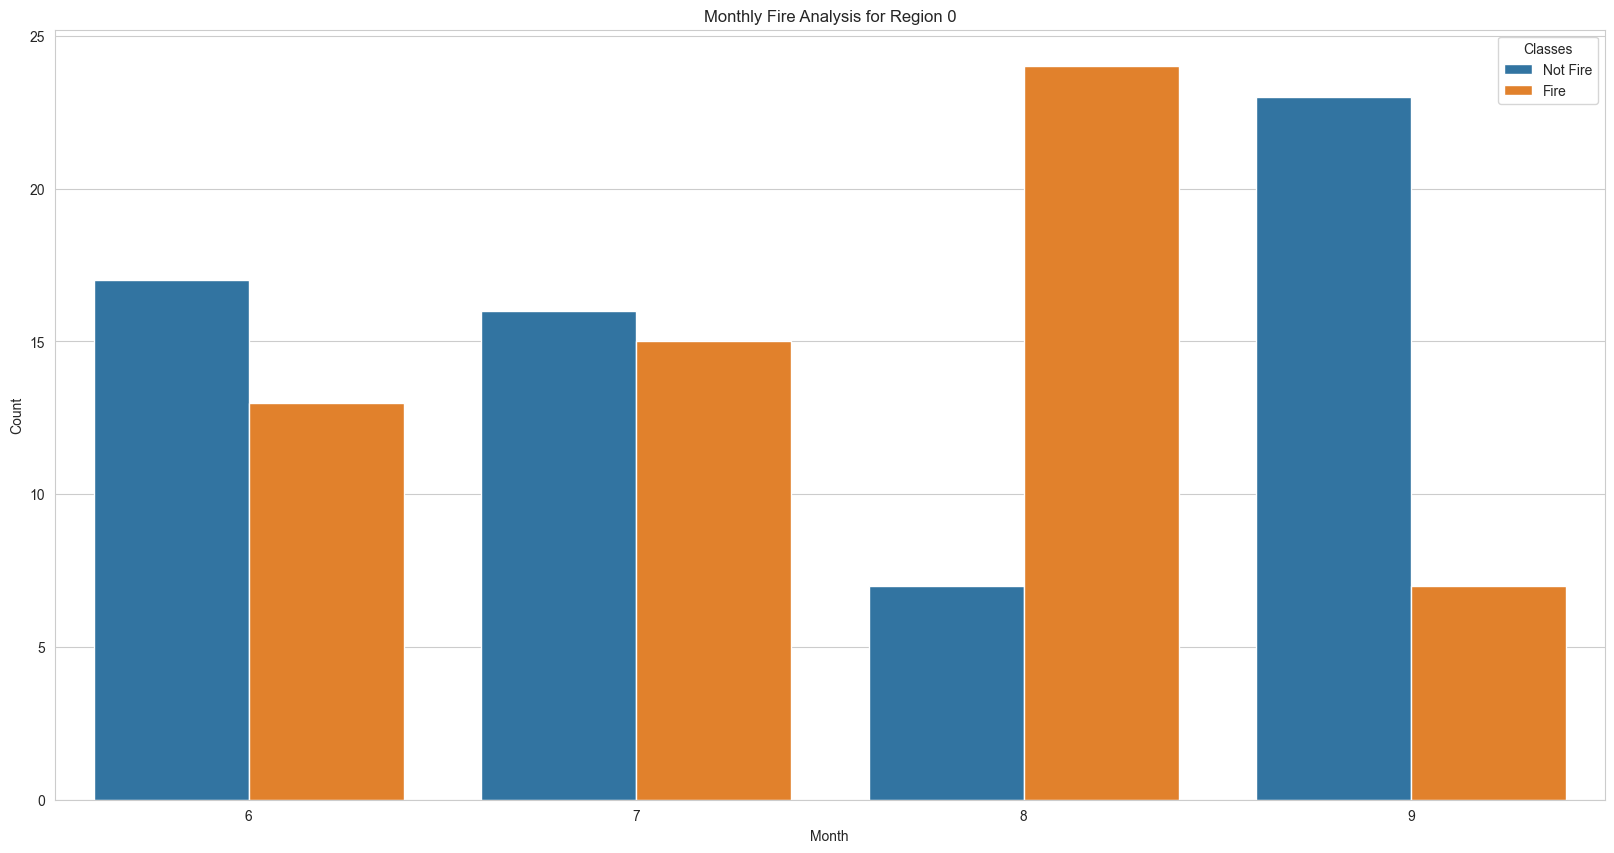

In [72]:
dftemp = df.loc[df['Region'] == 0]
plt.subplots(figsize=(20, 10))
sns.set_style('whitegrid')
sns.countplot(x = 'month', hue = 'Classes', data = dftemp)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Monthly Fire Analysis for Region 0')

plt.show()
